### Imports

In [1]:
import random
import warnings
from collections import defaultdict

import numpy as np
import torch

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.plotting_utils import visualise_spikes

warnings.filterwarnings('ignore', category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.SHIPSEAR
FILTERBANK = FilterbankType.MEL

### Visualise spikes

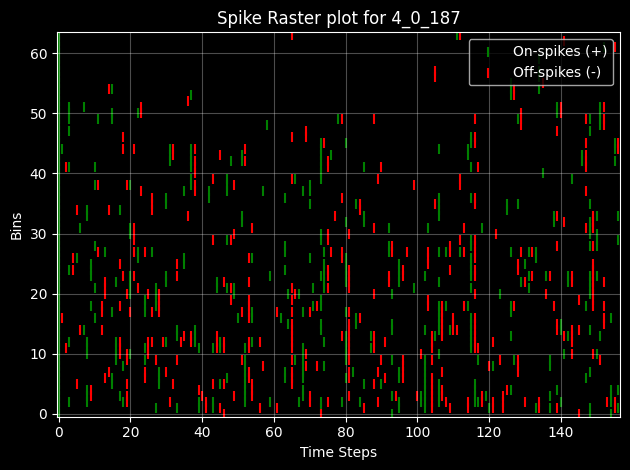

In [3]:
all_files = DATASET.get_spike_dir(FILTERBANK).rglob('*.pt')
random_file = random.choice(list(all_files))
file_name = random_file.stem
spikes = torch.load(random_file)
visualise_spikes(file_name, spikes)

### Densities

In [4]:
class_densities = defaultdict(list)

for spike_file in DATASET.get_spike_dir(FILTERBANK).rglob('*.pt'):
    class_id = int(spike_file.stem.split('_')[0])
    spikes = torch.load(spike_file)  # [T, 1, n_bins]
    T, _, n_bins = spikes.shape
    total_possible = T * n_bins
    count = (spikes != 0).sum().item()
    class_densities[class_id].append(count / total_possible * 100)

for cls in sorted(class_densities):
    d = class_densities[cls]
    print(f"Class {cls}: {np.mean(d):.1f}% ± {np.std(d):.1f}%")

all_d = [v for vs in class_densities.values() for v in vs]
print(f"\nOverall: {np.mean(all_d):.1f}% ± {np.std(all_d):.1f}%")

Class 0: 3.6% ± 1.3%
Class 1: 4.3% ± 3.8%
Class 2: 4.2% ± 2.6%
Class 3: 3.5% ± 1.4%
Class 4: 8.9% ± 3.6%

Overall: 4.4% ± 3.0%
